In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import astropy.io.fits as fits
import os
import glob
from astropy.table import Table
from astropy.io import ascii
from astropy.convolution import convolve, Box1DKernel, Gaussian1DKernel
import astropy.constants as const
import astropy.units as u
import importlib
from astropy.modeling import models, fitting
from astropy.time import Time


#matplotlib set up
%matplotlib inline
from matplotlib import rcParams
rcParams["figure.figsize"] = (14, 5)
rcParams["font.size"] = 20

In [2]:
path = '/media/david/2tb_ext_hd/hddata/carmenes_binary/lhs1817/hst/'
sx1s = glob.glob('{}*sx1.fits'.format(path))
cspecs = glob.glob('{}hasp/*cspec.fits'.format(path))
print(sx1s)
print(cspecs)


['/media/david/2tb_ext_hd/hddata/carmenes_binary/lhs1817/hst/ofem03010_sx1.fits', '/media/david/2tb_ext_hd/hddata/carmenes_binary/lhs1817/hst/ofem03020_sx1.fits']
['/media/david/2tb_ext_hd/hddata/carmenes_binary/lhs1817/hst/hasp/hst_17778_stis_lhs-1817_g230lb-g430l_ofem03_cspec.fits', '/media/david/2tb_ext_hd/hddata/carmenes_binary/lhs1817/hst/hasp/hst_17778_stis_lhs-1817_g230lb-g430l_ofem_cspec.fits', '/media/david/2tb_ext_hd/hddata/carmenes_binary/lhs1817/hst/hasp/hst_17778_stis_lhs-1817_g230lb_ofem03_cspec.fits', '/media/david/2tb_ext_hd/hddata/carmenes_binary/lhs1817/hst/hasp/hst_17778_stis_lhs-1817_g230lb_ofem_cspec.fits', '/media/david/2tb_ext_hd/hddata/carmenes_binary/lhs1817/hst/hasp/hst_17778_stis_lhs-1817_g430l_ofem03_cspec.fits', '/media/david/2tb_ext_hd/hddata/carmenes_binary/lhs1817/hst/hasp/hst_17778_stis_lhs-1817_g430l_ofem_cspec.fits']


/media/david/2tb_ext_hd/hddata/carmenes_binary/lhs1817/hst/ofem03010_sx1.fits
G230LB
/media/david/2tb_ext_hd/hddata/carmenes_binary/lhs1817/hst/ofem03020_sx1.fits
G430L


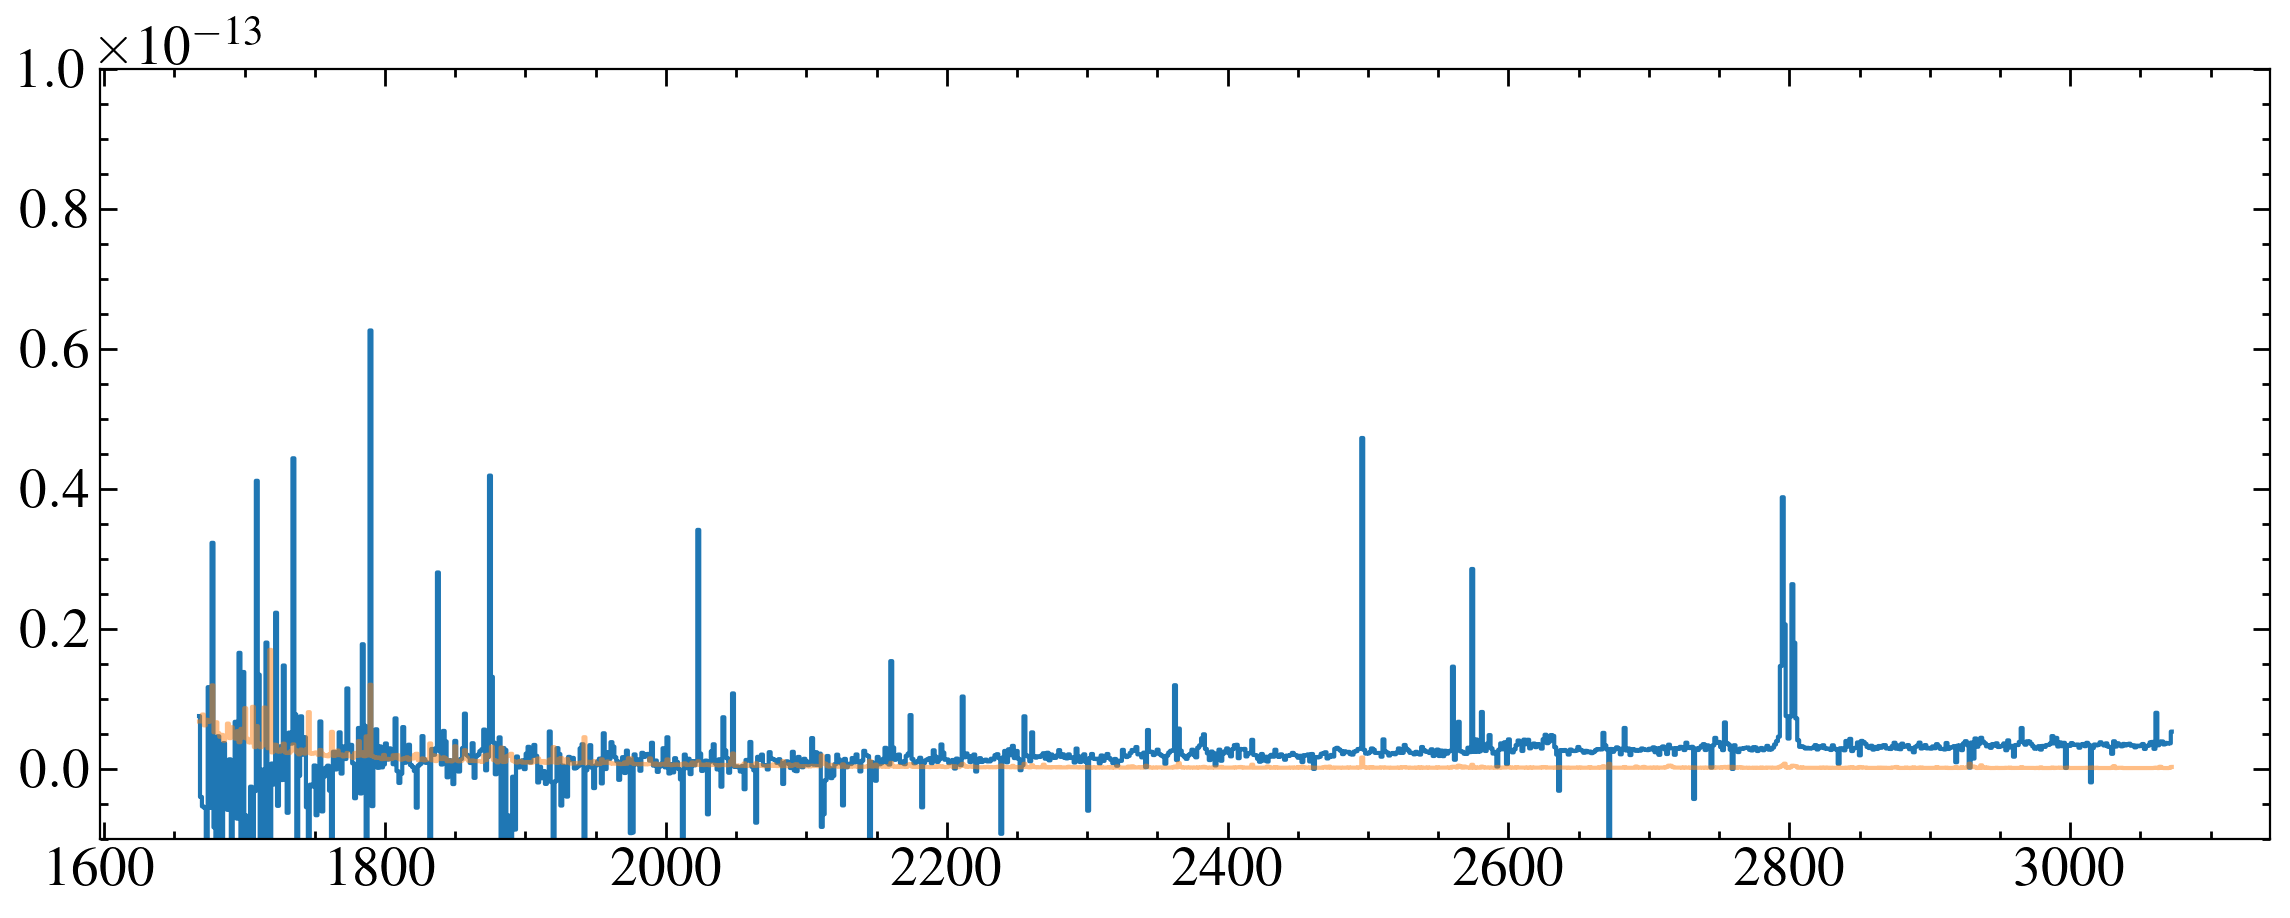

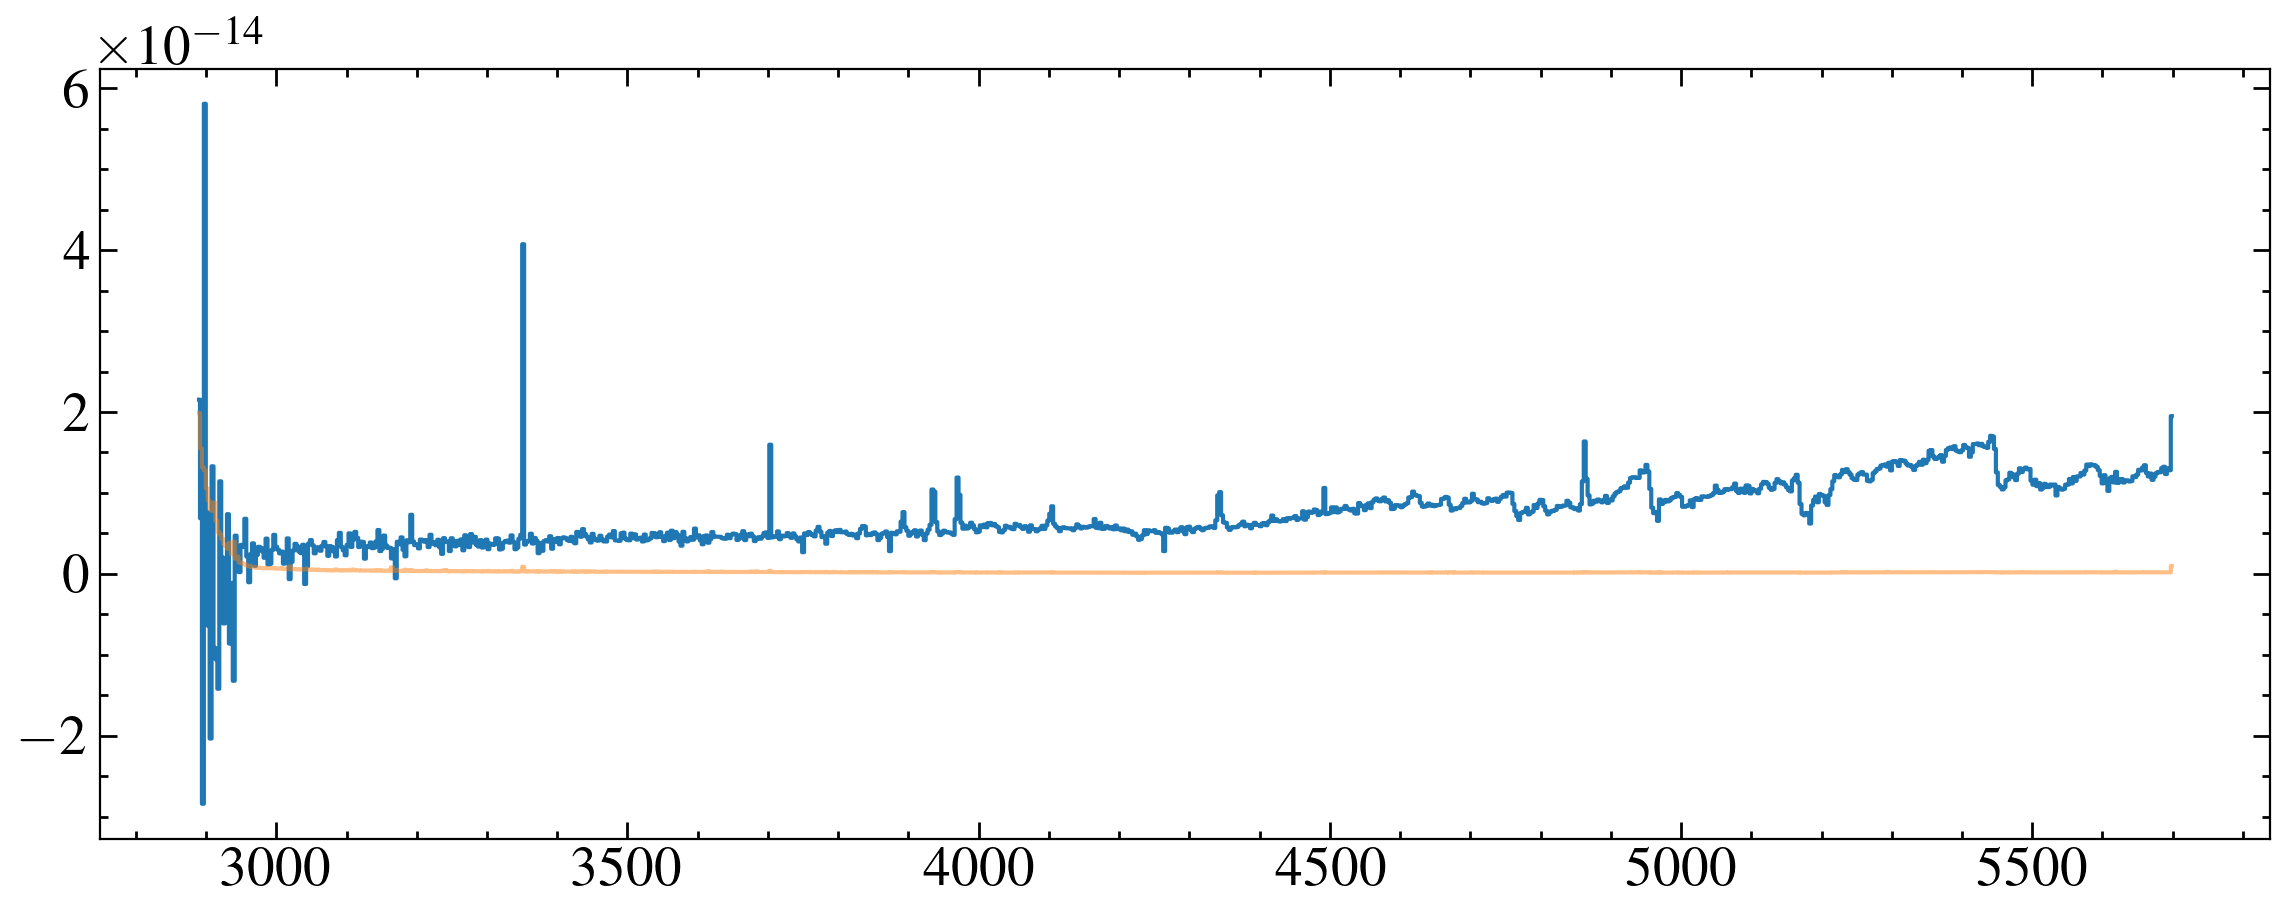

In [3]:
for x in sx1s:
    fig, ax = plt.subplots()
    print(x)
    grating = fits.getheader(x, 0)['OPT_ELEM'] 
    print(grating)
    data = fits.getdata(x, 1)[0]
    # print(data['A2Center'])
    w, f, e= data['WAVELENGTH'], data['FLUX'], data['ERROR']
    # if grating in ['G140M', 'G140L']:
        # mask = (w > 1160)
        
        # plt.ylim(-1e-16, 1e-16)
        # plt.axhline(0, ls='--', c='0.5')
    # if grating =='G230L':
    #     mask = (w > 1700)
    # if grating =='G430L':
    #     mask = (w > 3000)
    
    # w, f, e = w[mask], f[mask], e[mask]
    ax.step(w, f, where='mid')
    ax.step(w, e, where='mid', alpha=0.5)

    if grating == 'G230LB':
        ax.set_ylim(-1e-14, 1e-13)
    # plt.show()



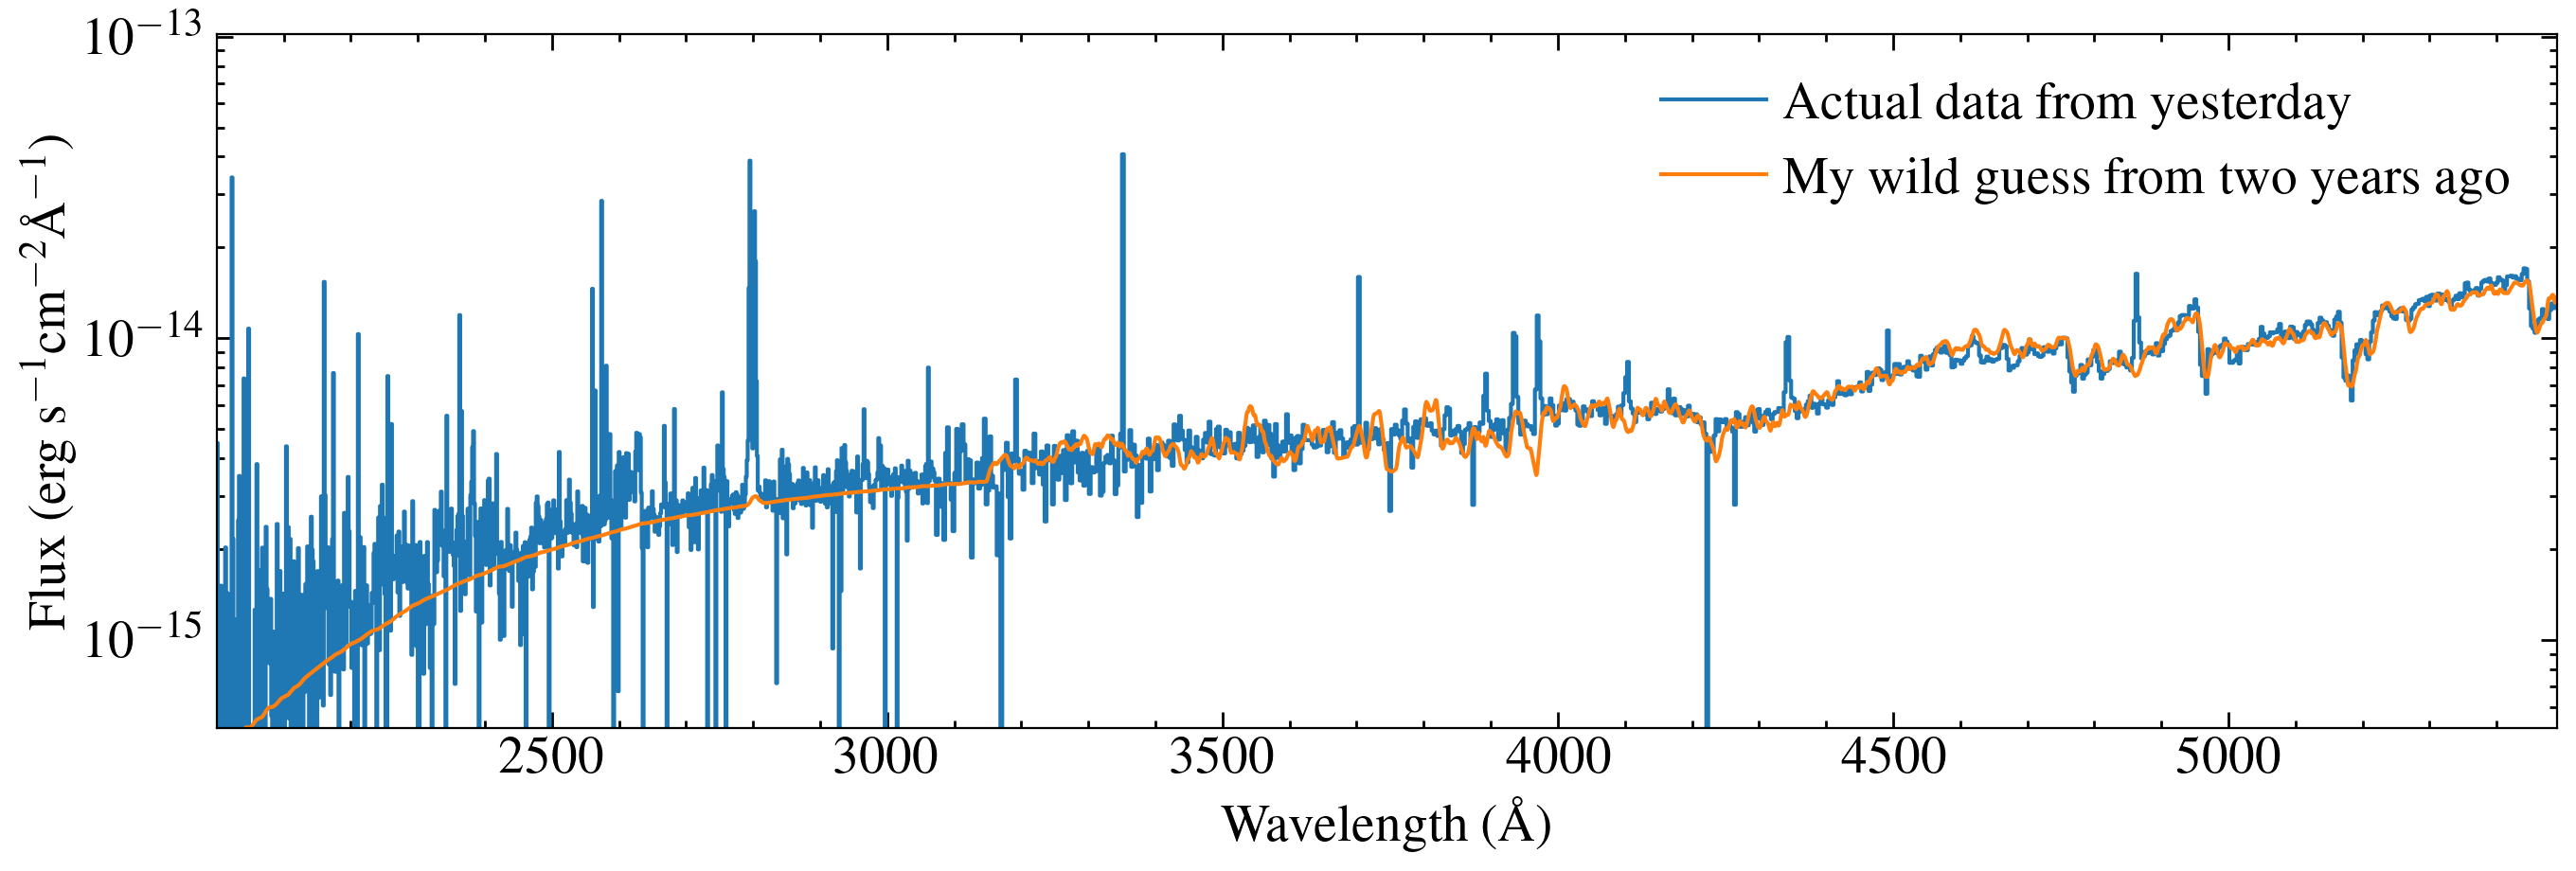

In [4]:
fig, ax = plt.subplots()

data = fits.getdata(cspecs[1], 1)[0]
w, f, e= data['WAVELENGTH'], data['FLUX'], data['ERROR']

mask = f < 1.5e-13

w, f, e = w[mask], f[mask], e[mask]

ax.step(w, f, where='mid', label='Actual data from yesterday')
# ax.step(w, e, where='mid', alpha=0.5)

ax.set_yscale('log')


mw, mf = np.loadtxt('lhs1817_model.dat', unpack=True)
mf = convolve(mf, Box1DKernel(10))

ax.plot(mw, mf*0.5, label = 'My wild guess from two years ago')

ax.set_ylim(5.1e-16)
ax.set_xlim(2001, 5490)
ax.legend()

ax.set_ylabel(r'Flux (erg s$^{-1}$cm$^{-2}$\AA$^{-1}$)', size=20)
ax.set_xlabel(r'Wavelength (\AA)', size=20)

fig.tight_layout()

/tmp/ipykernel_239139/171528443.py:10: RuntimeWarning: invalid value encountered in divide
  snr = convolve(f/e, Box1DKernel(5))


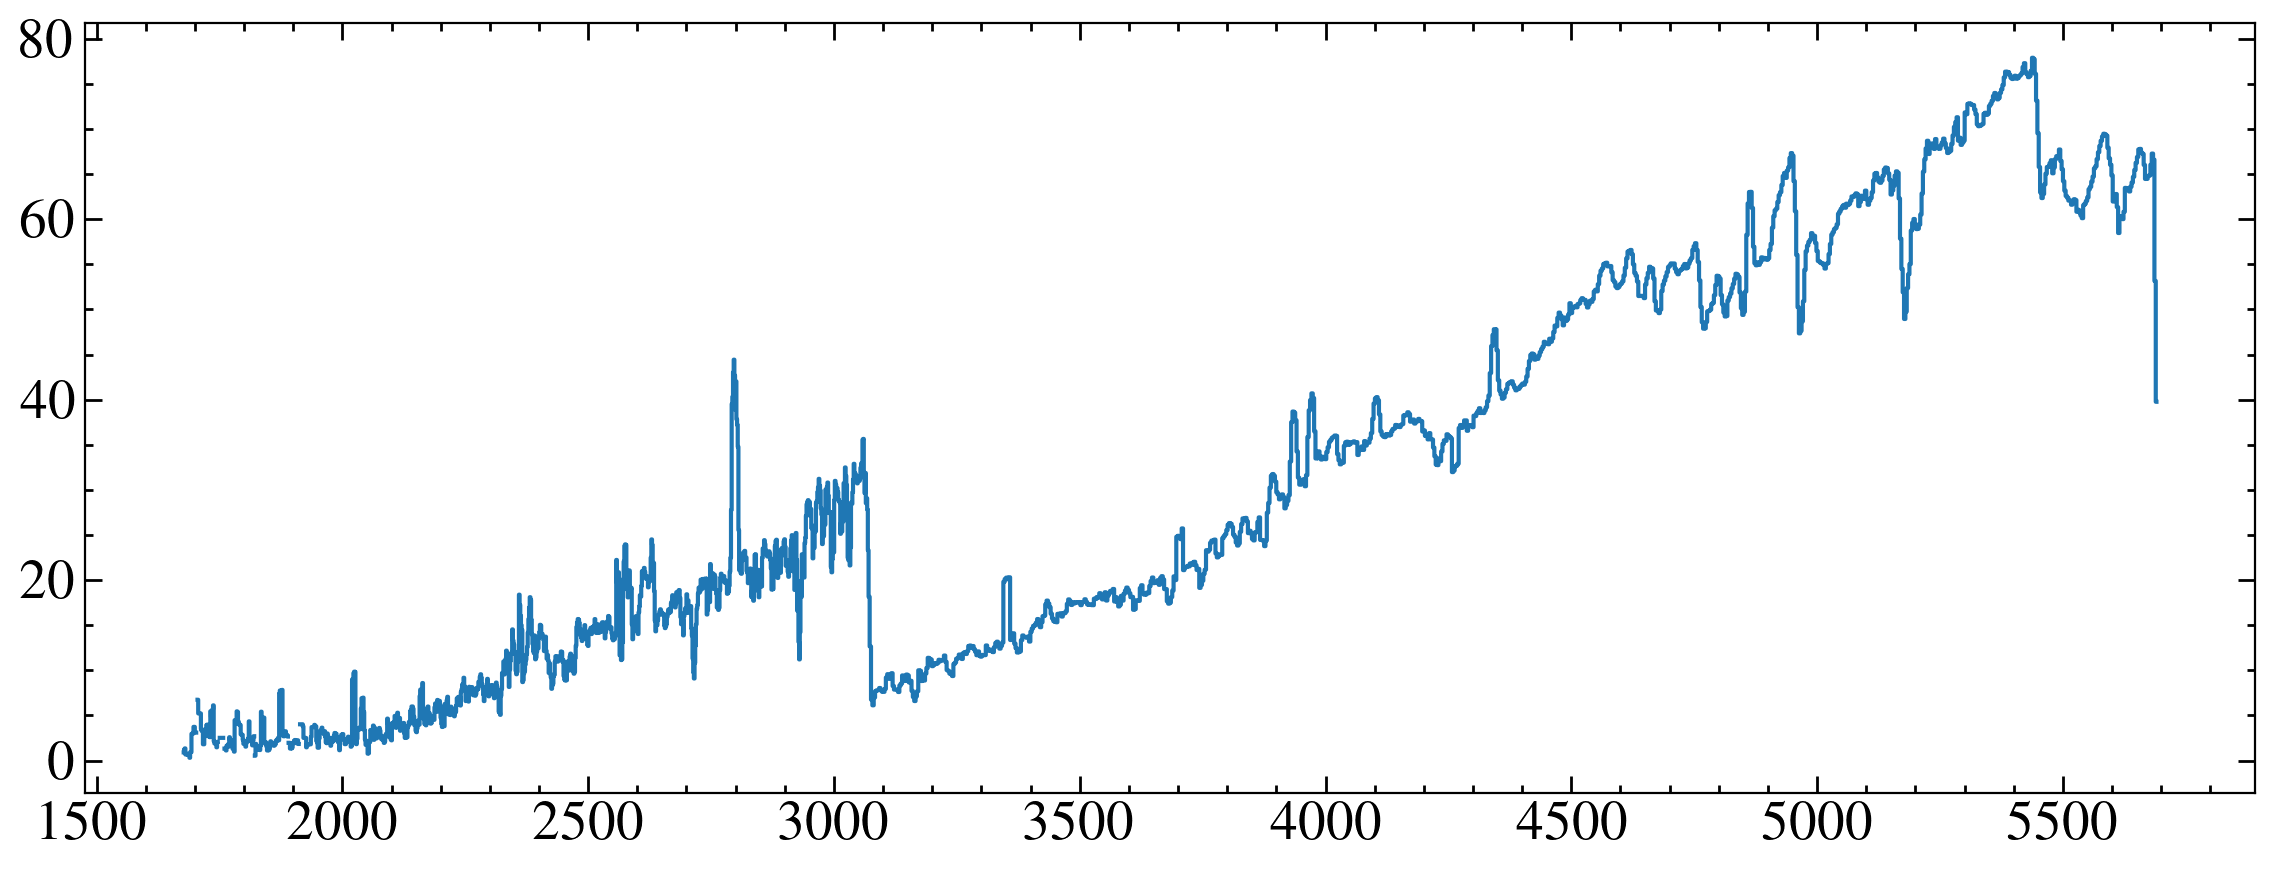

In [5]:
fig, ax = plt.subplots()

data = fits.getdata(cspecs[1], 1)[0]
w, f, e= data['WAVELENGTH'], data['FLUX'], data['ERROR']

mask = f < 1.5e-13

w, f, e = w[mask], f[mask], e[mask]

snr = convolve(f/e, Box1DKernel(5))

ax.step(w, snr, where='mid')



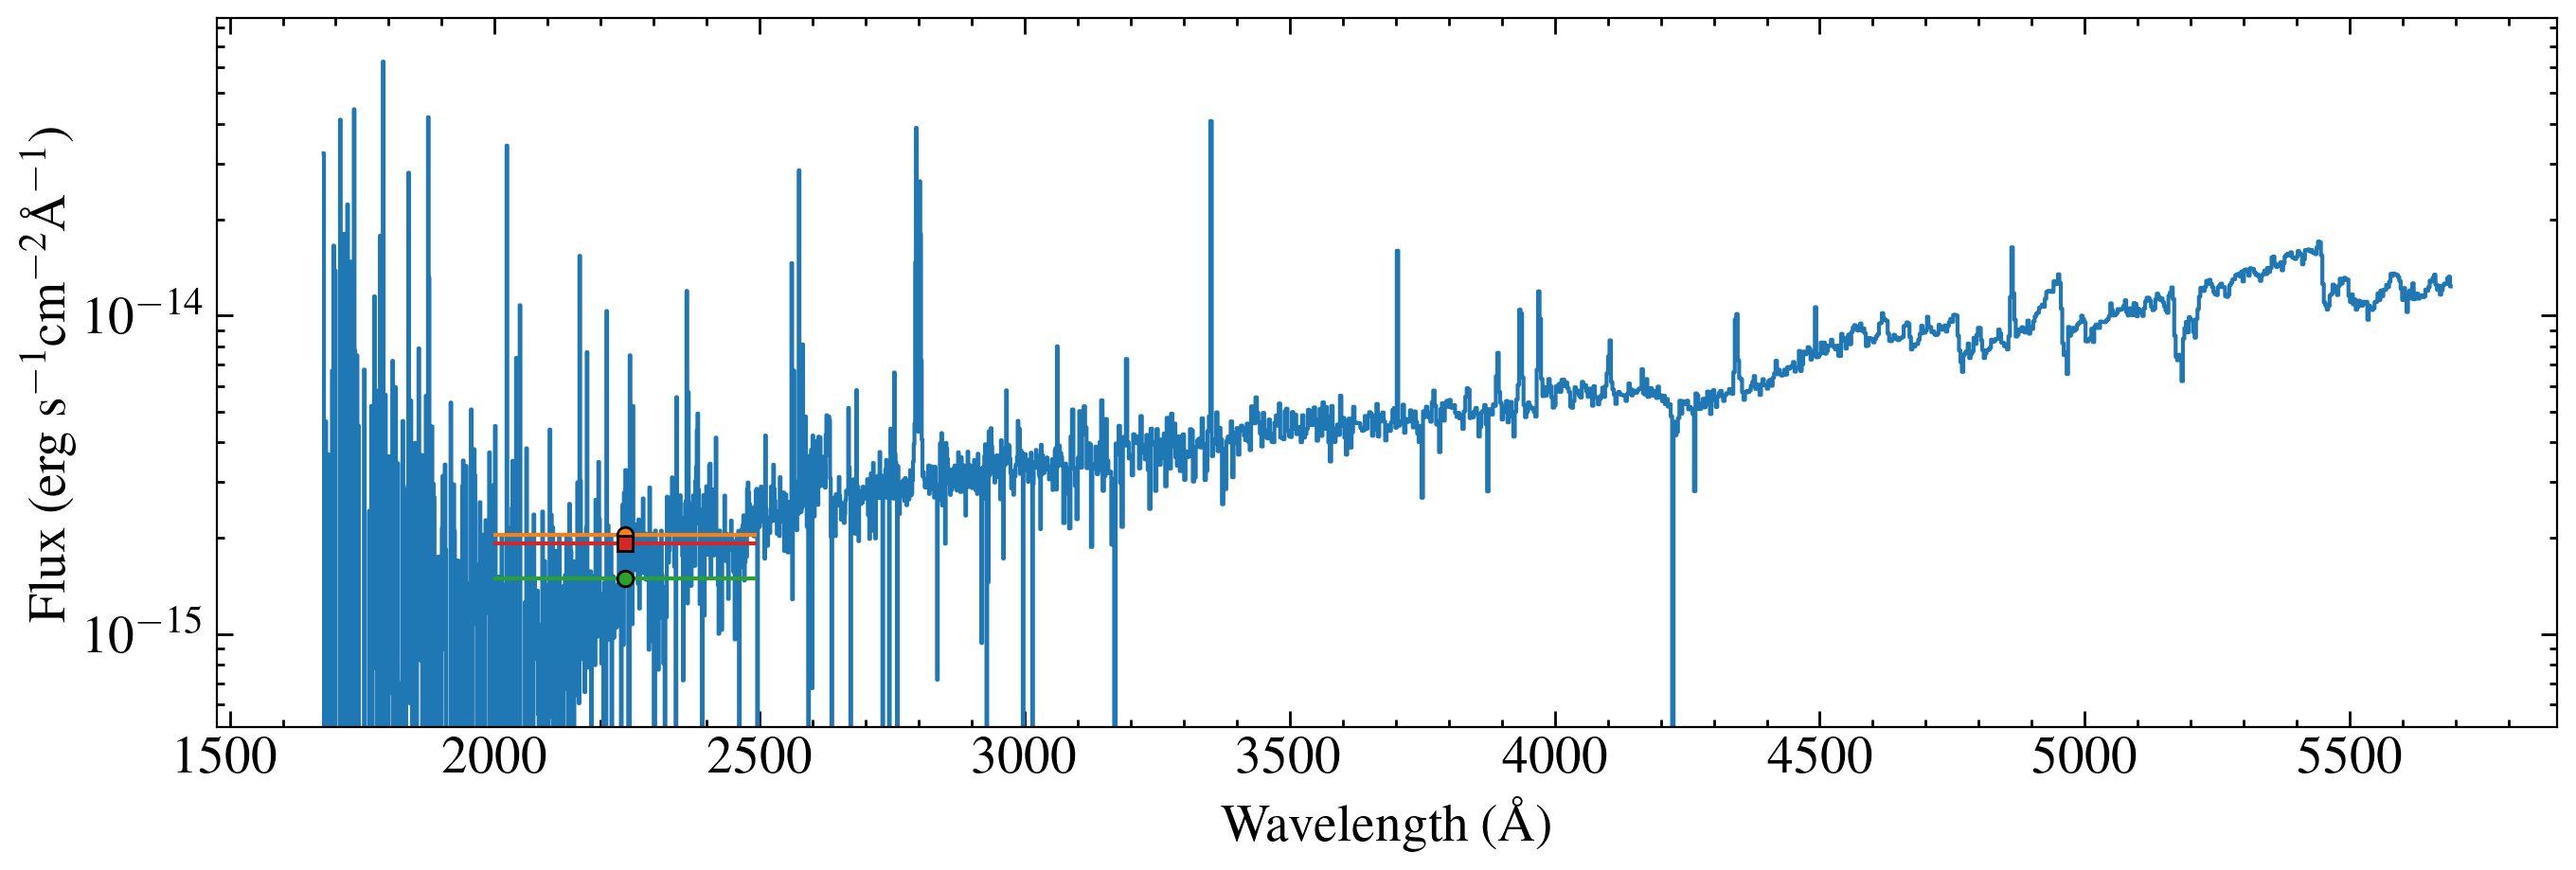

In [6]:
def make_phot(bp_w, bp_cc, w, f, e=0):
    mask = (w >= bp_w[0]) & (w <= bp_w[-1])
    w, f = w[mask], f[mask]
    bb_cci = np.interp(w, bp_w, bp_cc, left=0, right=0)
    flux = np.trapezoid(f*bb_cci, w)/np.trapezoid(bb_cci, w)
    if isinstance(e, int) != True:
        e = e[mask]
        intf = np.trapezoid(f, w)
        inte = (np.sum(e[1:]**2 * np.diff(w)**2))**0.5
        flux_error = (inte/intf)*flux
        return flux, flux_error
    else:
        return flux 
        
fig, ax = plt.subplots()

data = fits.getdata(cspecs[1], 1)[0]
w, f, e= data['WAVELENGTH'], data['FLUX'], data['ERROR']

# mask = f < 1.5e-13

# w, f, e = w[mask], f[mask], e[mask]

ax.step(w, f, where='mid')
# ax.step(w, e, where='mid', alpha=0.5)

ax.set_yscale('log')


ax.set_ylim(5.1e-16)
# ax.set_xlim(2001, 5490)
# ax.legend()

cenwaves = dict(V=5468, B=4392, U=3465,UVW1=2600, UVM2=2246, UVW2=1928)
fwhms = dict(V=769, B=975, U=785, UVW1=693, UVM2=498, UVW2=657)

spath = '/media/david/2tb_ext_hd/hddata/carmenes_binary/lhs1817/swift/00036027001/uvot/products/lhs_1817_uvm2_phot.fits'
data = fits.getdata(spath, 1)
sw, fwhm = cenwaves[data['FILTER'][0]], fwhms[data['FILTER'][0]]
sf, se = data['AB_FLUX_AA'], data['AB_FLUX_AA_ERR']

ax.errorbar(sw, sf, yerr=se, xerr=fwhm/2, marker='o', ls='none', markeredgecolor='k')


spath = '/media/david/2tb_ext_hd/hddata/carmenes_binary/lhs1817/swift/00036027002/uvot/products/lhs_1817_uvm2_phot.fits'
data = fits.getdata(spath, 1)
sw, fwhm = cenwaves[data['FILTER'][0]], fwhms[data['FILTER'][0]]
sf, se = data['AB_FLUX_AA'], data['AB_FLUX_AA_ERR']

ax.errorbar(sw, sf, yerr=se, xerr=fwhm/2, marker='o', ls='none', markeredgecolor='k')

ax.set_ylabel(r'Flux (erg s$^{-1}$cm$^{-2}$\AA$^{-1}$)', size=20)
ax.set_xlabel(r'Wavelength (\AA)', size=20)

bp_w, bp_cc = np.loadtxt('/home/david/work/filters/uvot/Swift_UVOT.UVM2.dat', unpack=True)

pre_phot, pre_phot_e = make_phot(bp_w, bp_cc, w, f, e=e)
ax.errorbar(sw, pre_phot, yerr=pre_phot_e, xerr=fwhm/2, marker='s', ls='none', markeredgecolor='k', label = 'STIS to UVM2 before correction')
uw, uf, ue = w, f, e 



fig.tight_layout()

900.0
950.0


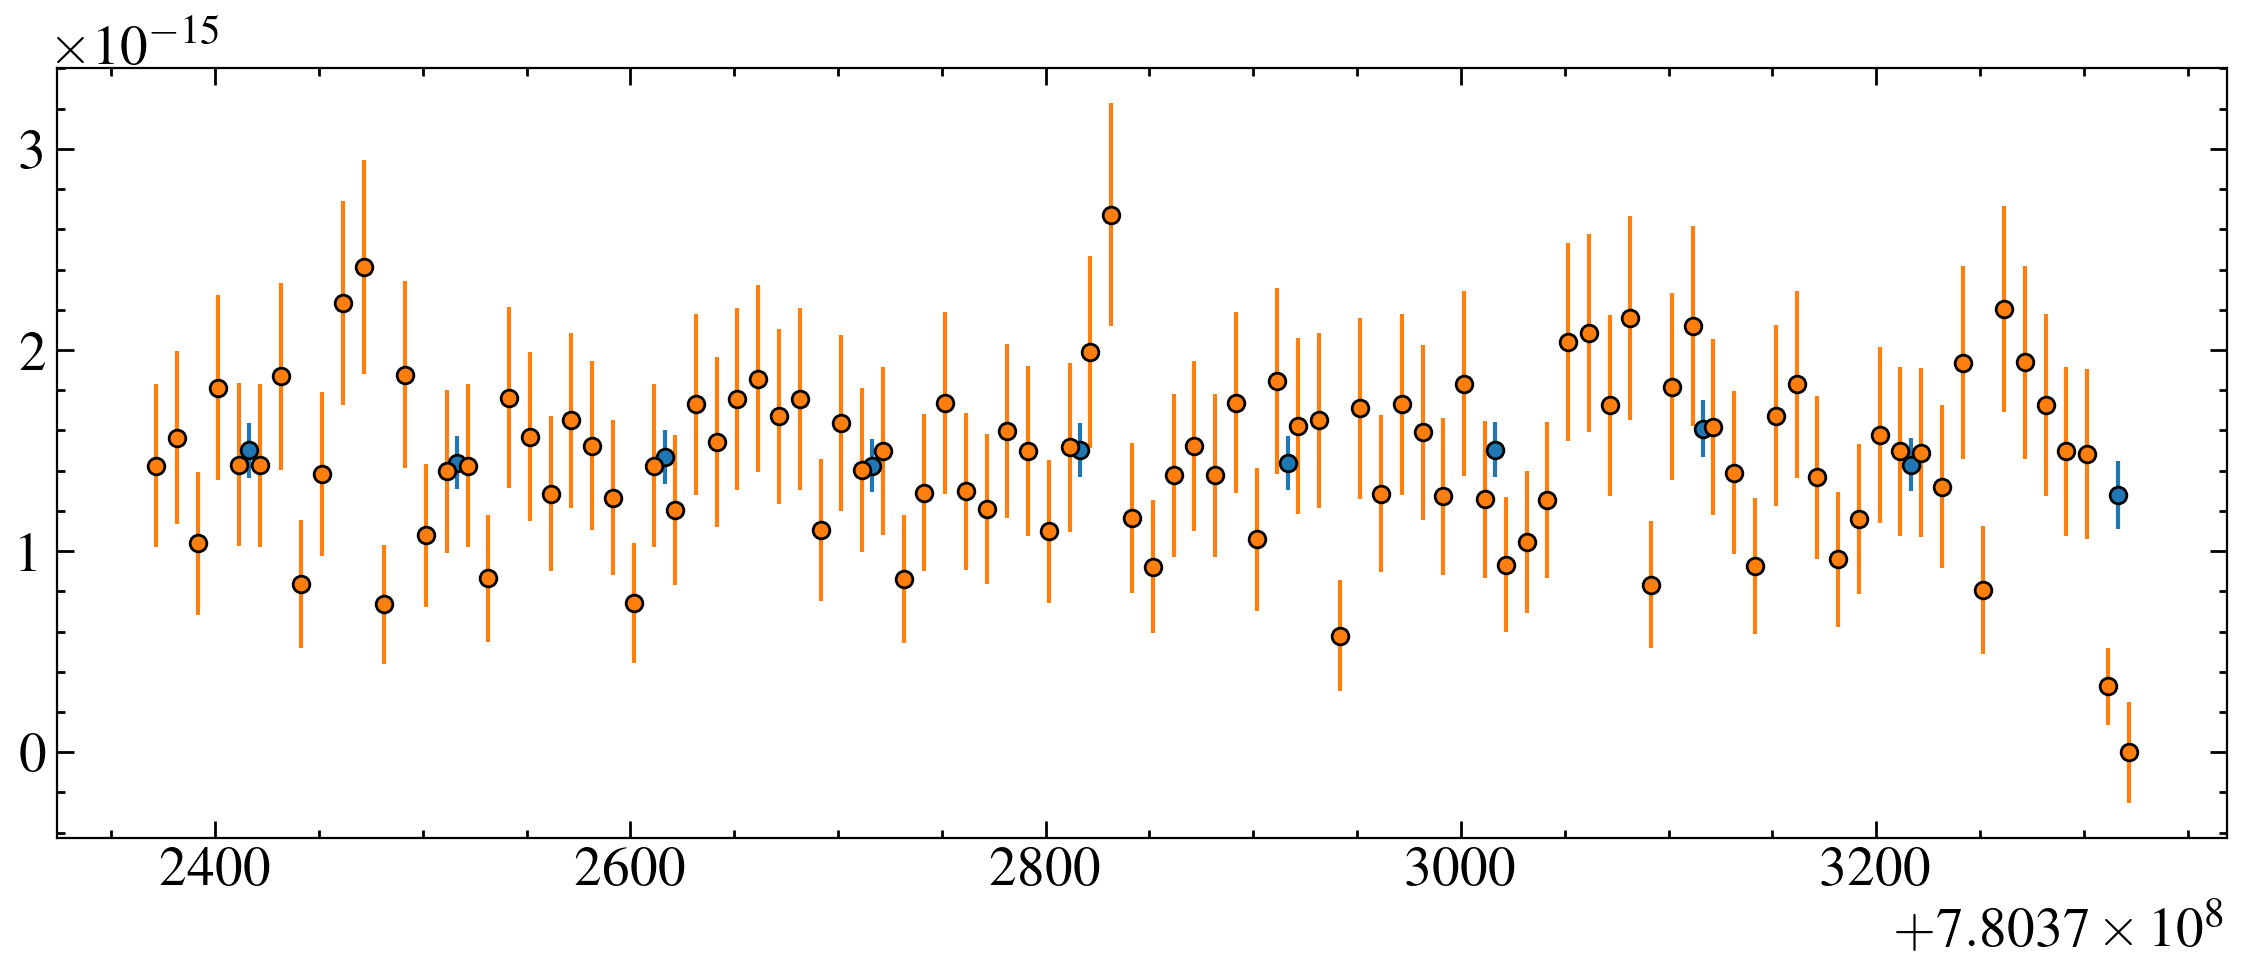

In [7]:
fig, ax = plt.subplots()

lc = fits.getdata('/media/david/2tb_ext_hd/hddata/carmenes_binary/lhs1817/swift/00036027002/uvot/products/lhs1817_uvm2_100s.fits', 1)
ax.errorbar(lc['TIME'], lc['AB_FLUX_AA'], yerr = lc['AB_FLUX_AA_ERR'], marker='o', ls='none', markeredgecolor='k')
print(lc['TIME'][-1] - lc['TIME'][0])

lc = fits.getdata('/media/david/2tb_ext_hd/hddata/carmenes_binary/lhs1817/swift/00036027002/uvot/products/lhs1817_uvm2_10s.fits', 1)
ax.errorbar(lc['TIME'], lc['AB_FLUX_AA'], yerr = lc['AB_FLUX_AA_ERR'], marker='o', ls='none', markeredgecolor='k')
print(lc['TIME'][-1] - lc['TIME'][0])

In [8]:
def fix_g230lb_scatter(fitsfile, Vmag, return_Slambda = False):
    """
    Fixes the scattered light in STIS G230LB with the cookbook from https://www.stsci.edu/files/live/sites/www/files/home/hst/instrumentation/stis/documentation/instrument-science-reports/_documents/2022_05.pdf
    """
    #collecting relevant information
    hdul = fits.open(fitsfile)
    data = hdul[1].data[0]
    wavelength, net, flux = data['WAVELENGTH'], data['NET'], data['FLUX']
    gain = hdul[0].header['ATODGAIN']
    net *= gain
    sensitivity = flux / net
    hdul.close()
    
    #calculating correction curve
    K0 = 426 * 10**(-0.4*Vmag)
    Slambda = K0 * (1.0+0.00104 * (wavelength - 2000))
    net_corr = net - Slambda
    flux_corr = net_corr * sensitivity

    if return_Slambda:
        return flux_corr, Slambda
    else:
        return flux_corr

In [9]:
vmag = 13.698


for x in sx1s:
    # print(x)
    hdul = fits.open(x)
    root = hdul[0].header['ROOTNAME']
    # dq = hdul[1].data[0]['DQ']
    # print(len(dq))
    # dq = np.zeros(len(dq))
    # hdul[1].data[0]['DQ'] = dq
    f_corr ,slambda= fix_g230lb_scatter(x, vmag,  return_Slambda =True)
    hdul[1].data[0]['FLUX'] = f_corr
    hdul.writeto('{}fluxcorr/{}_corr_fixed_dqs_sx1.fits'.format(path, root), overwrite=True)
    hdul.close()

2006 [2.0435403e-15] [5.163791e-17] [39.574417]
2025 [1.4934129e-15] [5.2998524e-17] [28.178387]
pre 1.926685677723631e-15 1.4172171660564595e-17
post 1.9023772730115203e-15 1.4105471719032506e-17 134.8680363836853 [1.27384548]


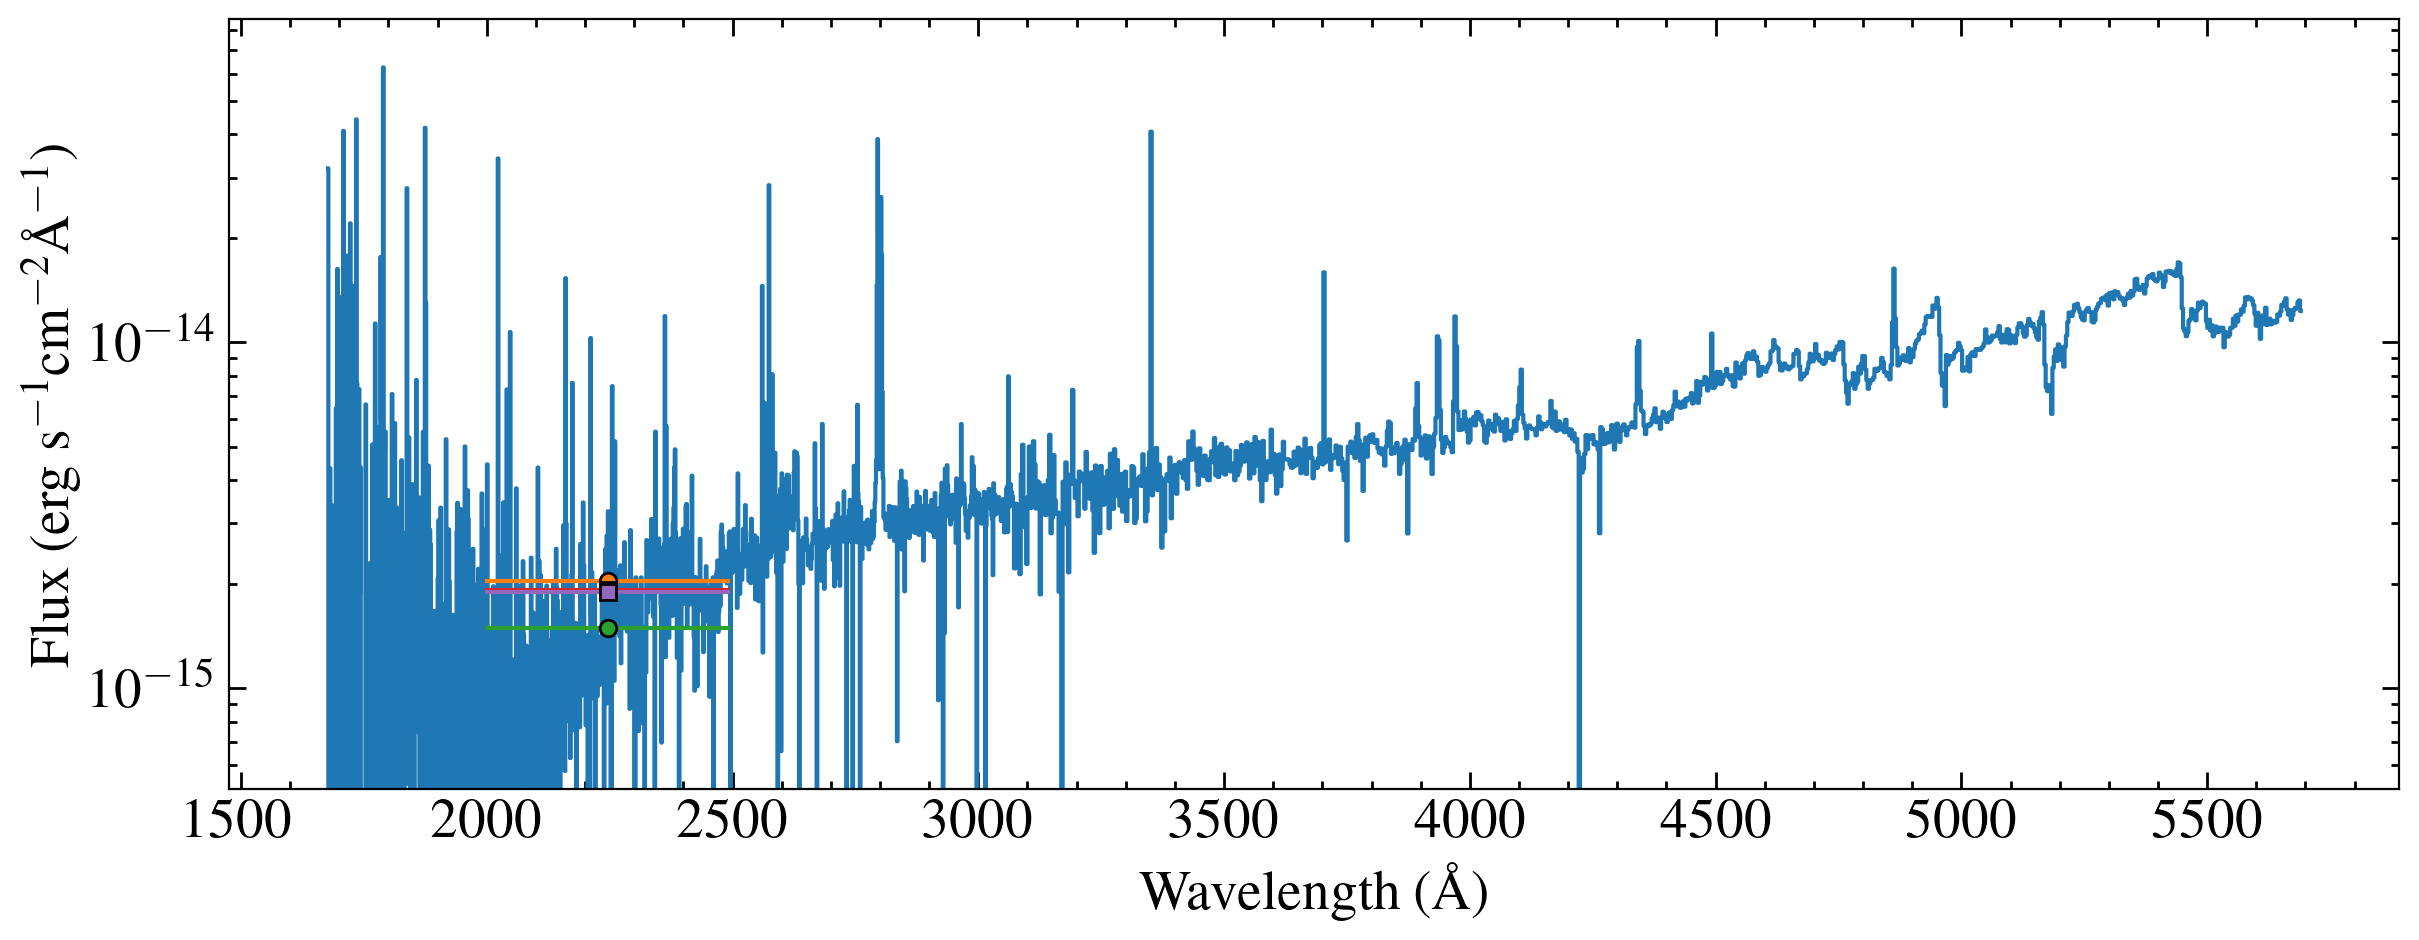

In [28]:
fig, ax = plt.subplots()

cspec = '{}fluxcorr/hst_17778_stis_lhs-1817_g230lb-g430l_corrected_cspec.fits'.format(path)

data = fits.getdata(cspec, 1)[0]
w, f, e= data['WAVELENGTH'], data['FLUX'], data['ERROR'], 

# w, f, e = w[dq ==0], f[dq==0], e[dq==0]

ax.step(w, f, where='mid')
# ax.step(w, e, where='mid', alpha=0.5)

ax.set_yscale('log')


ax.set_ylim(5.1e-16)
# ax.set_xlim(2001, 5490)
# ax.legend()

cenwaves = dict(V=5468, B=4392, U=3465,UVW1=2600, UVM2=2246, UVW2=1928)
fwhms = dict(V=769, B=975, U=785, UVW1=693, UVM2=498, UVW2=657)

spath = '/media/david/2tb_ext_hd/hddata/carmenes_binary/lhs1817/swift/00036027001/uvot/products/lhs_1817_uvm2_phot.fits'
data = fits.getdata(spath, 1)
sw, fwhm = cenwaves[data['FILTER'][0]], fwhms[data['FILTER'][0]]
sf, se = data['AB_FLUX_AA'], data['AB_FLUX_AA_ERR']

print('2006', sf, se, sf/se)

ax.errorbar(sw, sf, yerr=se, xerr=fwhm/2, marker='o', ls='none', markeredgecolor='k')


spath = '/media/david/2tb_ext_hd/hddata/carmenes_binary/lhs1817/swift/00036027002/uvot/products/lhs_1817_uvm2_phot.fits'
data = fits.getdata(spath, 1)
sw, fwhm = cenwaves[data['FILTER'][0]], fwhms[data['FILTER'][0]]
sf, se = data['AB_FLUX_AA'], data['AB_FLUX_AA_ERR']

print('2025', sf, se, sf/se)


ax.errorbar(sw, sf, yerr=se, xerr=fwhm/2, marker='o', ls='none', markeredgecolor='k')

ax.set_ylabel(r'Flux (erg s$^{-1}$cm$^{-2}$\AA$^{-1}$)', size=20)
ax.set_xlabel(r'Wavelength (\AA)', size=20)

bp_w, bp_cc = np.loadtxt('/home/david/work/filters/uvot/Swift_UVOT.UVM2.dat', unpack=True)

# pre_phot, pre_phot_e = make_phot(bp_w, bp_cc, w, f, e=e)
ax.errorbar(sw, pre_phot, yerr=pre_phot_e, xerr=fwhm/2, marker='s', ls='none', markeredgecolor='k', label = 'STIS to UVM2 before correction')


post_phot, post_phot_e = make_phot(bp_w, bp_cc, w, f, e=e)
ax.errorbar(sw, post_phot, yerr=post_phot_e, xerr=fwhm/2, marker='s', ls='none', markeredgecolor='k', label = 'STIS to UVM2 before correction')

print('pre', pre_phot, pre_phot_e)
print('post', post_phot, post_phot_e, post_phot/post_phot_e, post_phot/sf)



Have to extract the flt files and see if there's a difference? Doesn't seem to be by eye.


In [35]:
proxies = [ 'gj876', 'GJ729', 'L-980-5']
teff = [3201, 3248, 3278]
survey = ['m', 'mm', 'mm']
prot = [96.7, 2.8, 92.2]
dists = [ 1000/213.8669, 3.0, 13.3]*u.pc
mpath = '/media/david/2tb_ext_hd/hddata/mega_muscles/'
dstar = (1000/61.43)*u.pc


gj876
GJ729
L-980-5


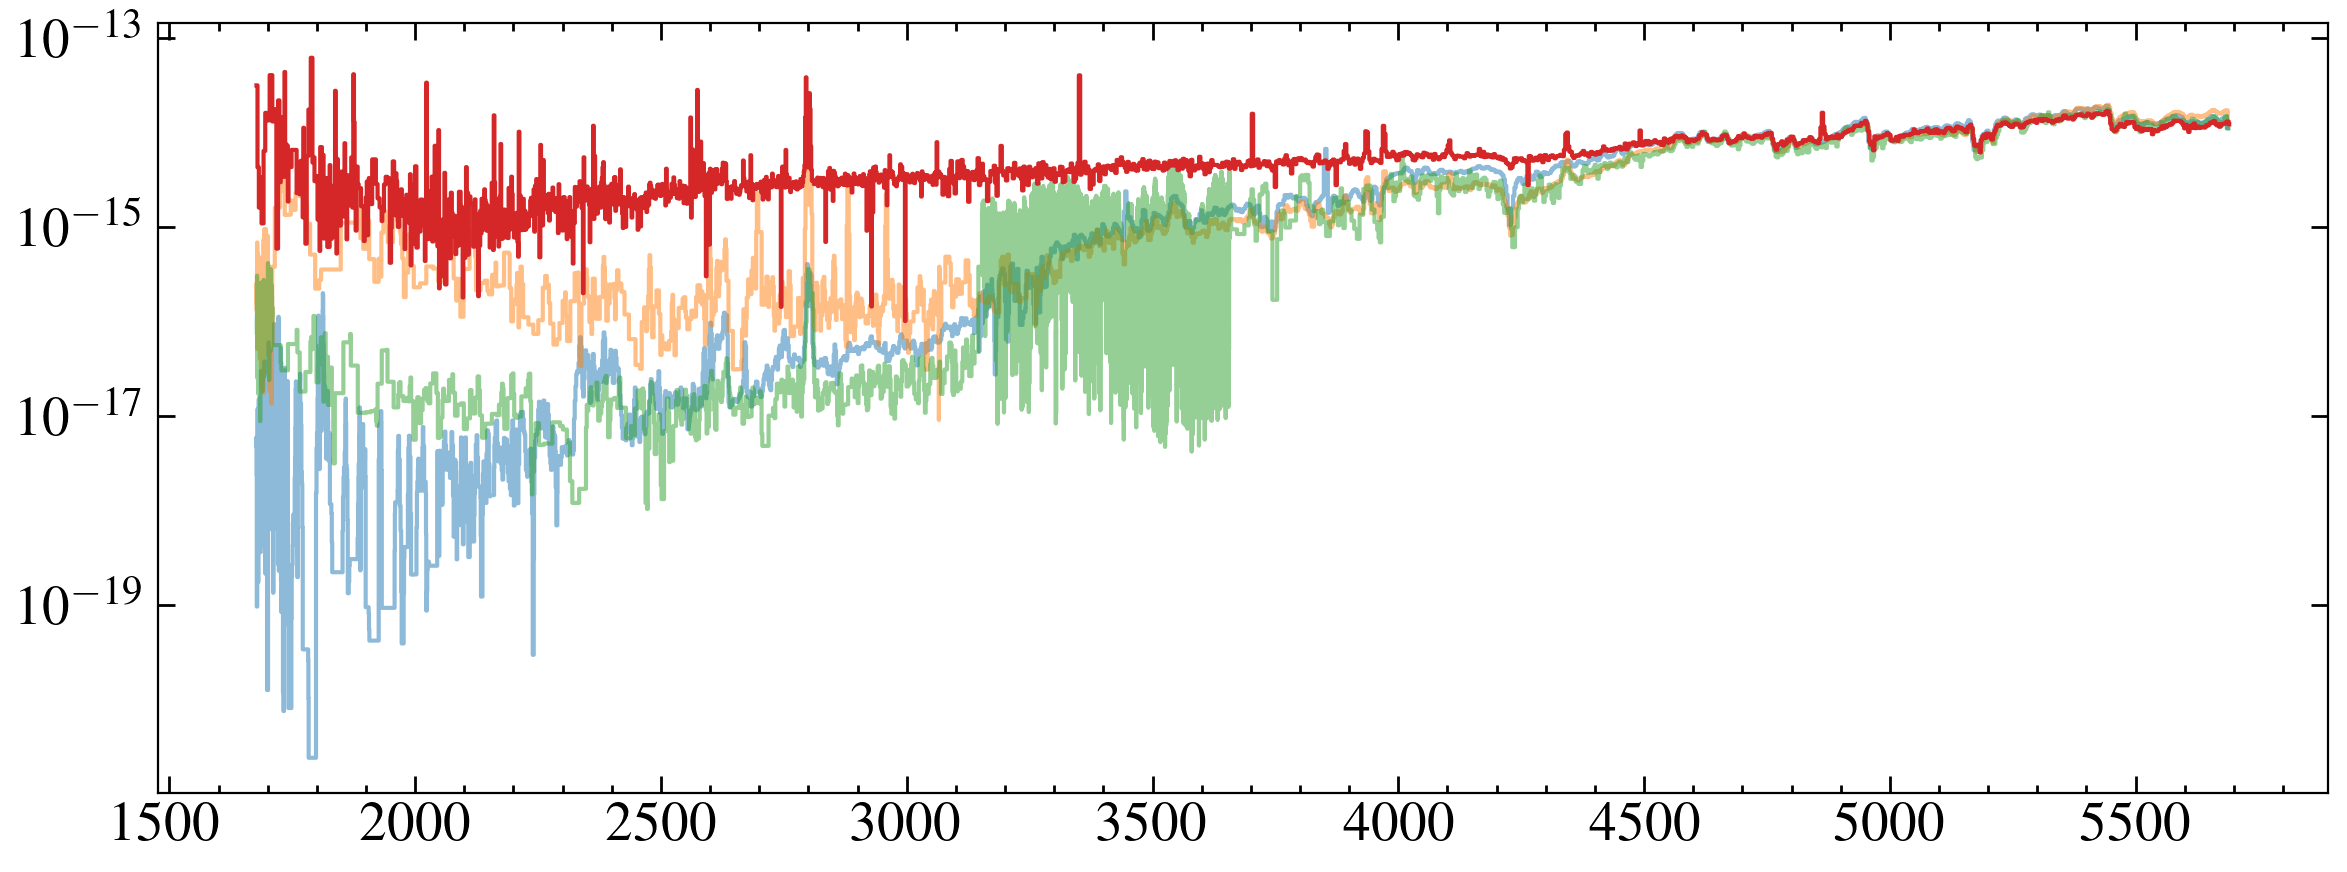

In [36]:
fig, ax = plt.subplots()
pscale = [0.7, 2, 1]
for i, proxy in enumerate(proxies):
    print(proxy)
    starpath = '{}v26_hlsp_fixed/{}/'.format(mpath, proxy)
    if survey[i] == 'm':
        starpath = '{}muscles_hlsp/{}/'.format(mpath, proxy)
    scale = (dists[i]/dstar)**2
    sedpath = glob.glob('{}*var-res-sed.fits'.format(starpath))[0]
    sed = fits.getdata(sedpath, 1)
    pw, pf = sed['WAVELENGTH'], sed['FLUX']
    mask = (pw >= (w[0])) & (pw <=(w[-1]))
    # mask = (pw >= 1900) & (pw <=5690)
    pw, pf = pw[mask], pf[mask]
    pfi = convolve(pf, Box1DKernel(2))
    
    ax.step(pw, pfi*scale*pscale[i], alpha=0.5)
    # savdat = Table([pw, pf], names=['WAVELENGTH', 'FLUX'])
    # savdat.write('models/{}_proxy_spectrum.csv'.format(proxy), format='csv', overwrite=True)
ax.set_yscale('log')


ax.step(w[f > 1e-17], f[f > 1e-17], where='mid')


Extract subspectra from flt files, then re-do GJ 729 spectrum 

In [13]:
# import stistools
# os.environ['oref'] = path


In [14]:
# flt = '{}ofem03010_flt.fits'.format(path)

# rootname = fits.getheader(flt)['ROOTNAME'] 
# outname = '{}reextractions/{}_new_sx1.fits'.format(path, rootname)
# stistools.x1d.x1d(flt, output = outname, trailer='{}reextractions/{}_new.trl'.format(path, rootname))


509.2251
1.5281784335794836e-15 6.178377947260276e-17 24.73429833241482
509.19757
1.9213915275159003e-15 6.506117354322946e-17 29.532076088963326
0.7953498345832782


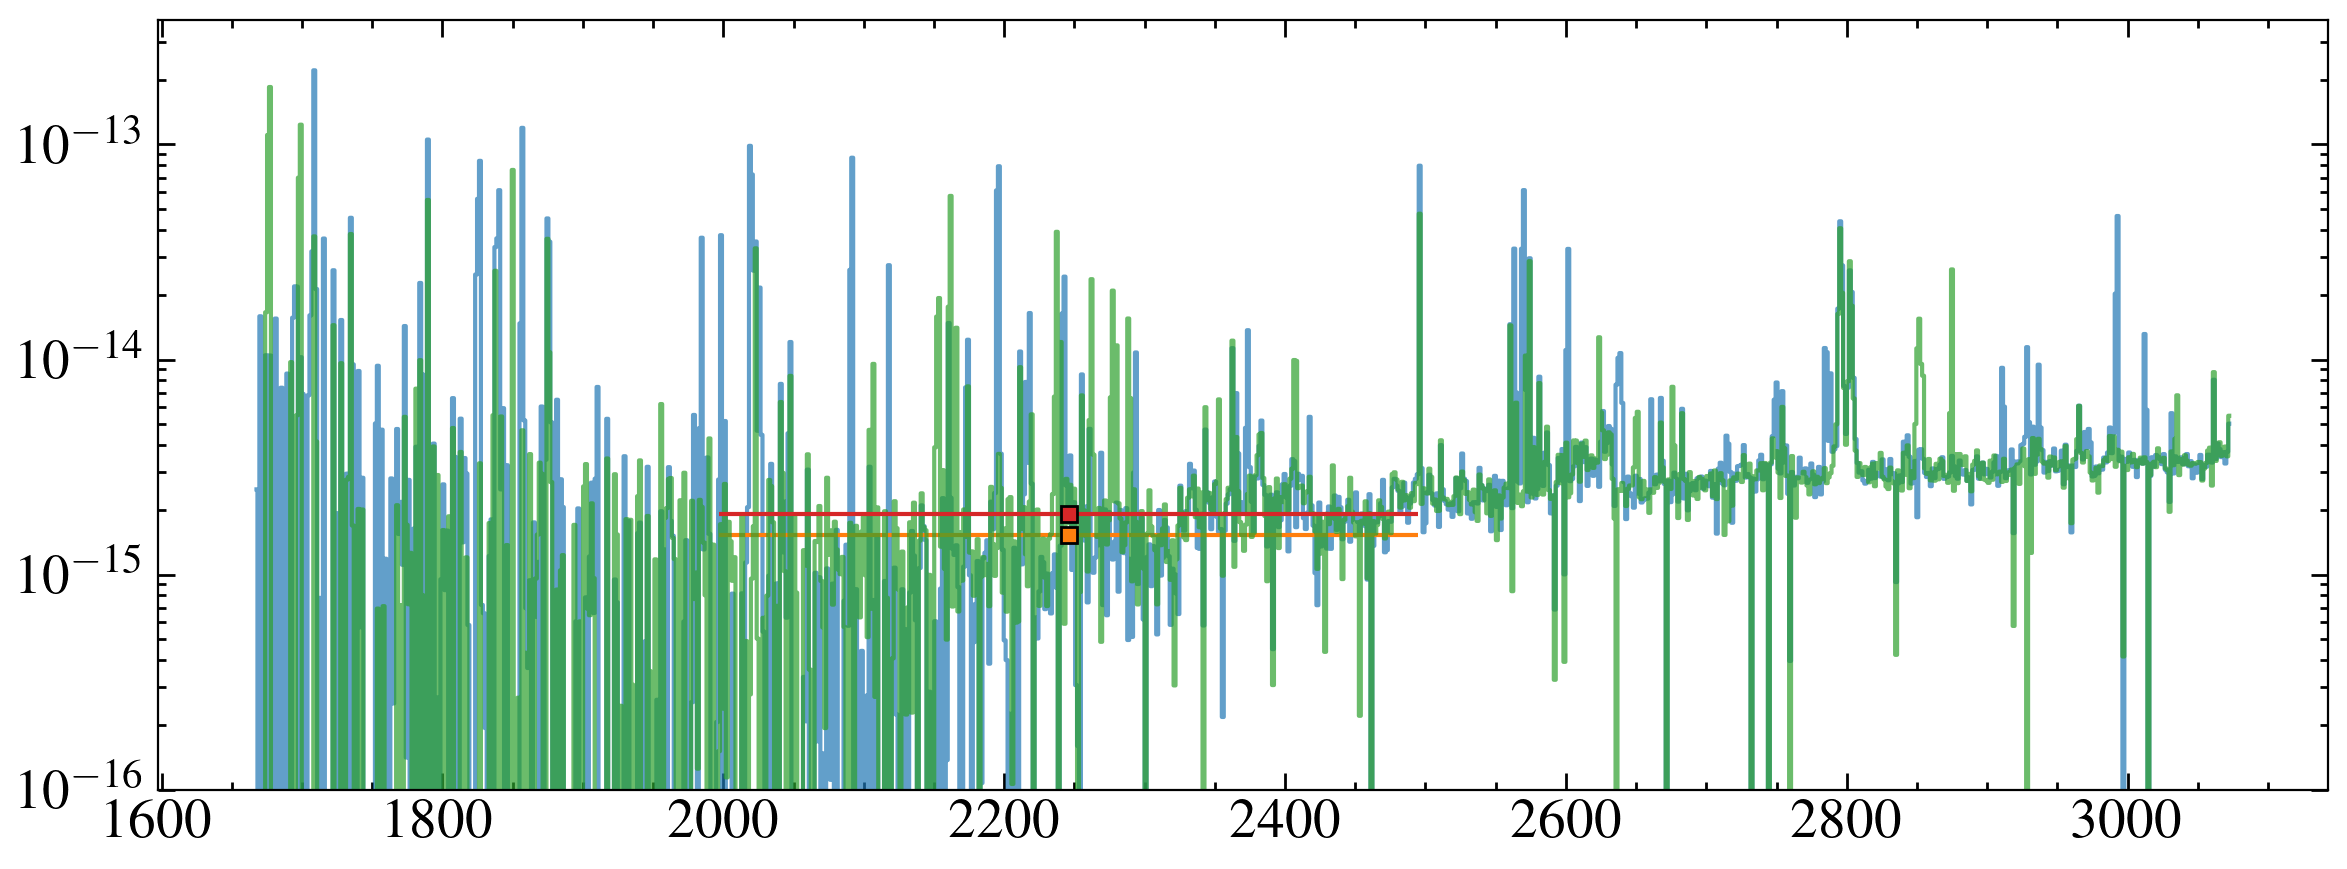

In [32]:
subspecs = '{}reextractions/ofem03010_new_sx1.fits'.format(path)
fig, ax = plt.subplots()

phots = []

for i in [1, 2]:
    data = fits.getdata(subspecs, i)[0]
    ax.step(data['WAVELENGTH'], data['FLUX'], where='mid', alpha=0.7)
    print(data['A2CENTER'])
    phot, phot_e = make_phot(bp_w, bp_cc,data['WAVELENGTH'][data['DQ'] < 7], data['FLUX'][data['DQ'] < 7], e=data['ERROR'][data['DQ'] < 7])
    ax.errorbar(sw, phot, yerr=phot_e, xerr=fwhm/2, marker='s', ls='none', markeredgecolor='k')
    phots.append(phot)
    print(phot, phot_e, phot/phot_e)


ax.set_yscale('log')
# ax.set_xscale('log')
ax.set_ylim(1e-16)

print(phots[0]/phots[1])



Ok that's confusing. GJ 729 then come back to it? 

In [34]:
gjpath = '/media/david/2tb_ext_hd/hddata/carmenes_binary/gj729/hst'

#230ls not in cspecs. hmm. not extracted.

#I did the extractions in MM wrong, oops,.